## VBE Style Modular Multiplication

- https://arxiv.org/pdf/2306.09122
- https://arxiv.org/pdf/quant-ph/9511018

In [2]:
# !pip install qiskit_aer
%matplotlib inline

import sys
sys.path.append("../src")

from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from mod_adder_vbe import mod_adder_vbe
from mod_mult_vbe import mod_mult_vbe
from qiskit import transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import math

In [7]:
N_val = 15
k_values = range(15)
y_val = 1

results = []
results_calc = []

for k in k_values:
    n = math.ceil(math.log2(N_val + 1))
    m = n + 1
    
    ctrl = QuantumRegister(1, "ctrl")
    a = QuantumRegister(m, 'a') 
    b = QuantumRegister(m, 'b')
    c = QuantumRegister(m-1, 'c')
    N = QuantumRegister(m, 'N')
    t = QuantumRegister(1, 't')
    y = QuantumRegister(m, 'y')
    creg = ClassicalRegister(m, 'creg')
    
    qc = QuantumCircuit(ctrl, a, b, c, N, t, y, creg)
    
    # load modular adder
    mod_add = mod_adder_vbe(m, N_val) # for overflow we need one additional qubit
    mod_mult = mod_mult_vbe(m, k, N_val, mod_add)

    # prepare N
    for i in range(n):
        if (N_val >> i) & 1:
            qc.x(N[i])
    
    # prepare y
    for i in range(n):
        if (y_val >> i) & 1:
            qc.x(y[i])
    
    # activate control
    qc.x(ctrl[0])
    
    # append adder gate
    qc.append(mod_mult, [ctrl[0]] + a[:] + b[:] + c[:] + N[:] + [t[0]] + y[:])
    
    # measure circuit
    qc_measure = qc.copy()
    qc_measure.measure(y, creg)
    
    sim = AerSimulator(method="matrix_product_state")
    
    tqc = transpile(qc_measure, sim)
    
    nbr_shots = 2**12
    result = sim.run(tqc, shots=nbr_shots).result()
    counts = result.get_counts()

    # write results to list
    for count, prob in counts.items():
        results.append(int(count, 2))

    results_calc.append((y_val * k) % N_val)

In [8]:
results_calc

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [9]:
results

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

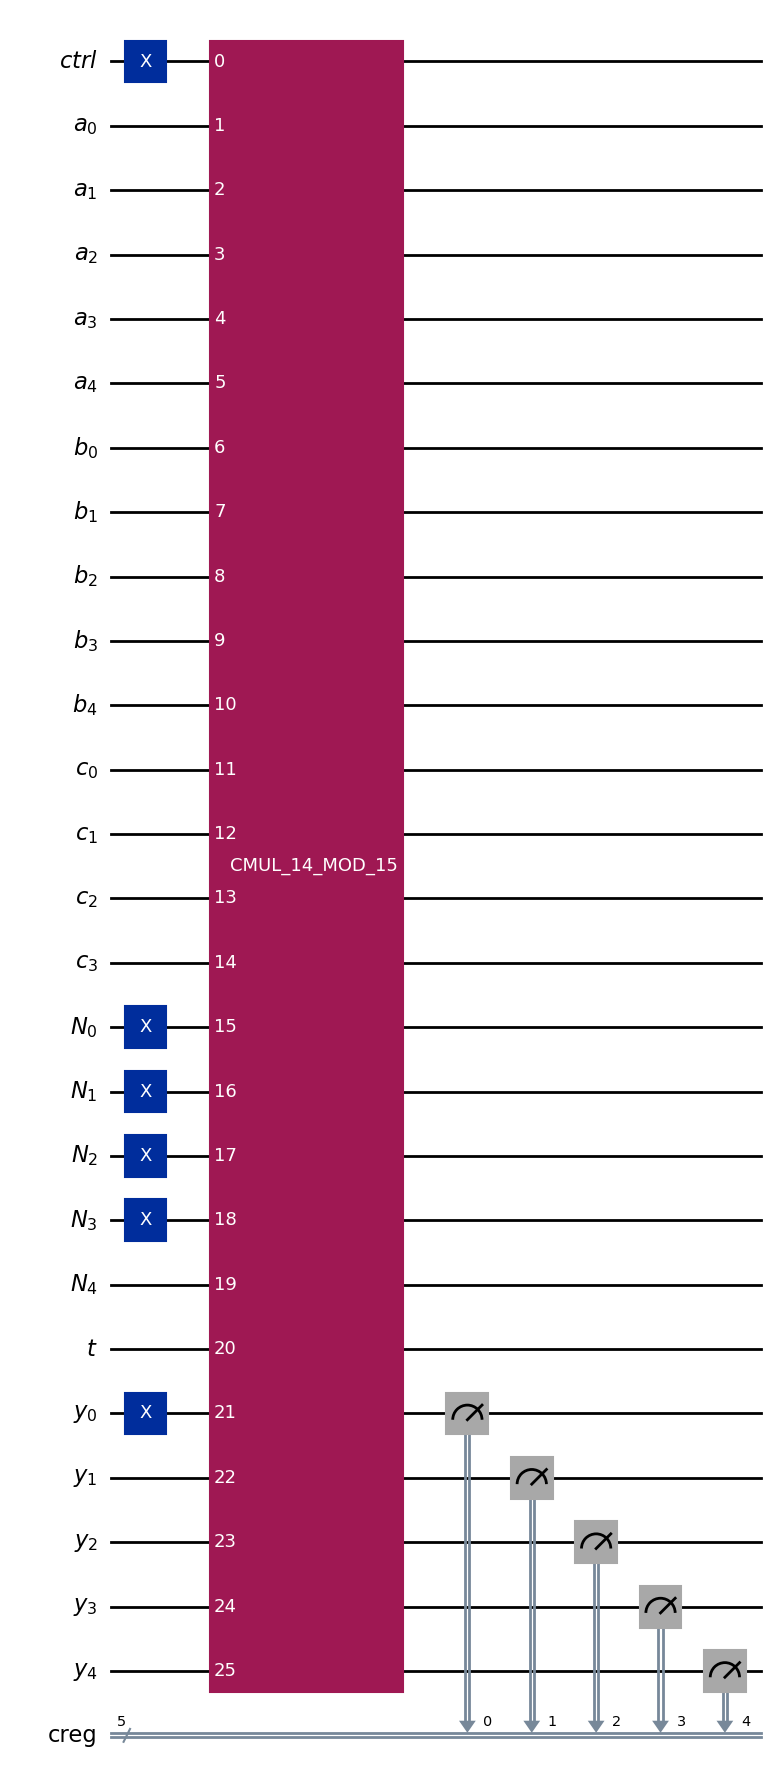

In [10]:
qc_measure.draw('mpl')